### STEP 0. 제출용 Notebook과 Chapter10 입력 준비

In [30]:
from pathlib import Path
import pandas as pd

# 챕터 10용으로 전처리한 데이터가 있는 폴더를 지정한다.
project_root = Path(r"C:\dev\llm-data-analysis-course-ch10")

# 전처리된 주문 데이터를 읽는다.
orders = pd.read_csv(project_root / "data" / "processed" / "orders_clean.csv")

# 데이터 크기, 컬럼, 주문 상태별 건수를 확인한다.
print("읽은 폴더:", project_root)
print("주문 데이터 크기:", orders.shape)
print("컬럼:", orders.columns.tolist())
print("\n주문 상태별 건수:")
print(orders["order_status"].value_counts(dropna=False))

읽은 폴더: C:\dev\llm-data-analysis-course-ch10
주문 데이터 크기: (300, 7)
컬럼: ['order_id', 'customer_id', 'order_date', 'payment_method', 'order_status', 'order_month', 'order_dayofweek']

주문 상태별 건수:
order_status
completed    184
cancelled     64
refunded      52
Name: count, dtype: int64


### STEP 1. Target Contract와 예측 시점 정의

### STEP 1. 타깃과 예측 시점

- **예측 대상:** 주문이 취소될지 여부
- **예측 단위:** 주문 1건
- **타깃 정의:** `completed`는 `is_cancelled = 0`, `cancelled`는 `is_cancelled = 1`로 둔다. `refunded`와 기타 상태는 이번 모델링에서 제외한다.
- **예측 시점:** 주문이 생성된 직후
- **사용 가능한 정보:** 주문 생성 직후 이미 확인할 수 있는 주문상품의 수량·가격과 그 이전에 기록된 고객 정보만 후보 특징으로 검토한다.
- **사용하면 안 되는 정보:** `order_status`, `is_cancelled`, 취소 사유·취소 시각처럼 예측 시점 이후에 알 수 있는 정보는 입력 특징에서 제외한다. `order_id`, `customer_id`, `product_id`도 식별자이므로 제외한다.

주문 상태를 입력 특징으로 사용하면 정답을 미리 알려주는 데이터 누수가 발생한다. 따라서 컬럼이 데이터에 존재하는지뿐 아니라, 실제 예측 시점에 알 수 있는 정보인지 확인해야 한다.

In [51]:
from pathlib import Path
import pandas as pd

# 필터링 전 파일은 백업 폴더에서 읽는다.
source_dir = project_root / "data" / "processed_before_ch10_temporal_filter"
processed_dir = project_root / "data" / "processed"

source_orders = pd.read_csv(source_dir / "orders_clean.csv")
source_items = pd.read_csv(source_dir / "order_items_clean.csv")
source_customers = pd.read_csv(source_dir / "customers_clean.csv")

# 주문일과 고객 가입일을 연결해 날짜 관계를 검사한다.
date_audit = source_orders[
    ["order_id", "customer_id", "order_date", "order_status"]
].merge(
    source_customers[["customer_id", "signup_date"]],
    on="customer_id",
    how="left",
    validate="many_to_one",
)

order_dates = pd.to_datetime(date_audit["order_date"])
signup_dates = pd.to_datetime(date_audit["signup_date"])

# 이번 타깃 범위에서 가입일이 주문일보다 늦은 주문을 찾는다.
invalid_target = (
    date_audit["order_status"].isin(["completed", "cancelled"])
    & (signup_dates > order_dates)
)
excluded_orders = date_audit.loc[invalid_target]
excluded_ids = set(excluded_orders["order_id"])

# 문제 주문과 그 주문에 속한 상품 행을 함께 제외한다.
filtered_orders = source_orders.loc[
    ~source_orders["order_id"].isin(excluded_ids)
].copy()
filtered_items = source_items.loc[
    source_items["order_id"].isin(filtered_orders["order_id"])
].copy()

# 제외 후에도 주문과 주문상품의 연결 관계가 유지되는지 확인한다.
assert filtered_orders["order_id"].is_unique
assert set(filtered_items["order_id"]) == set(filtered_orders["order_id"])

# 공식 분류 스크립트가 읽는 processed 파일을 갱신한다.
# 원본 raw와 백업 폴더의 파일은 수정하지 않는다.
filtered_orders.to_csv(processed_dir / "orders_clean.csv", index=False)
filtered_items.to_csv(processed_dir / "order_items_clean.csv", index=False)

# 노트북의 이후 셀도 같은 필터링 결과를 사용하게 한다.
orders = filtered_orders
order_items = filtered_items
customers = source_customers

# 공개해도 되는 집계 건수만 별도 기록한다.
exclusion_summary = pd.DataFrame([
    {"item": "원래 주문", "count": len(source_orders)},
    {"item": "날짜 역전으로 제외한 completed", "count":
     int((excluded_orders["order_status"] == "completed").sum())},
    {"item": "날짜 역전으로 제외한 cancelled", "count":
     int((excluded_orders["order_status"] == "cancelled").sum())},
    {"item": "제외 후 주문", "count": len(filtered_orders)},
    {"item": "제외 후 모델링 대상", "count":
     int(filtered_orders["order_status"].isin(["completed", "cancelled"]).sum())},
    {"item": "제외 후 주문상품 행", "count": len(filtered_items)},
])

reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)
exclusion_summary.to_csv(
    reports_dir / "ch10_temporal_exclusion_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

display(exclusion_summary)

,item,count
0,원래 주문,300
1,날짜 역전으로 제외한 completed,35
2,날짜 역전으로 제외한 cancelled,10
3,제외 후 주문,255
4,제외 후 모델링 대상,203
5,제외 후 주문상품 행,649


In [31]:
# 이번 분류에 사용할 두 가지 주문 상태만 남긴다.
target_orders = orders.loc[
    orders["order_status"].isin(["completed", "cancelled"])
].copy()

# 취소 주문은 1, 완료 주문은 0으로 표시한다.
target_orders["is_cancelled"] = (
    target_orders["order_status"] == "cancelled"
).astype(int)

# 제외 건수와 타깃 분포를 확인한다.
print("모델링 대상:", len(target_orders))
print("제외한 refunded 주문:", len(orders) - len(target_orders))
print("\n타깃별 건수:")
print(target_orders["is_cancelled"].value_counts().sort_index())
print("\n타깃별 비율(%):")
print((target_orders["is_cancelled"].value_counts(normalize=True).sort_index() * 100).round(2))

모델링 대상: 248
제외한 refunded 주문: 52

타깃별 건수:
is_cancelled
0    184
1     64
Name: count, dtype: int64

타깃별 비율(%):
is_cancelled
0    74.19
1    25.81
Name: proportion, dtype: float64


### 결과 관찰

전체 주문 300건 중 `completed`는 184건, `cancelled`는 64건, `refunded`는 52건이다. `refunded`를 제외한 모델링 대상은 248건이다. 타깃 `is_cancelled=0`은 184건(74.19%), `is_cancelled=1`은 64건(25.81%)이다.

### 나의 해석과 판단

완료 주문이 취소 주문보다 많다. 모든 주문을 완료로만 예측해도 전체 모델링 데이터 기준 74.19%의 accuracy가 나오므로, accuracy만으로 취소 탐지 성능을 판단하지 않겠다. 이후 취소 주문의 Precision, Recall, F1을 함께 확인하겠다.

### 업무·분석적 의미

주문 생성 직후 취소 가능성이 있는 주문을 찾아내는 것이 목적이다. 취소 주문을 놓치는 경우(FN)와 정상 주문을 취소 위험으로 잘못 표시하는 경우(FP)의 비용은 이후 평가 결과와 업무 조건을 함께 보고 판단해야 한다.

### 한계와 추가 확인 사항

현재 확인한 것은 타깃 분포이며, 아직 모델 성능은 측정하지 않았다. `refunded` 주문은 분석 대상에서 제외했으므로 이 모델의 결과를 환불 주문에 적용할 수 없다. 후보 특징이 주문 생성 직후 실제로 사용 가능한지도 Feature Audit에서 확인해야 한다.

### STEP 2. 주문 단위 특징과 계산 관계 검증

In [32]:
# STEP 2-1. 전처리된 주문상품 파일을 읽는다.
order_items = pd.read_csv(
    project_root / "data" / "processed" / "order_items_clean.csv"
)

# 계산과 집계에 사용할 컬럼이 있는지 확인한다.
print("주문상품 데이터 크기:", order_items.shape)
print("컬럼:", order_items.columns.tolist())
display(order_items.head())

주문상품 데이터 크기: (764, 6)
컬럼: ['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price', 'line_total']


,order_item_id,order_id,product_id,quantity,unit_price,line_total
0,1,1,100,3,102000,306000
1,2,1,87,5,25000,125000
2,3,1,7,3,142000,426000
3,4,1,9,3,193000,579000
4,5,2,72,4,189000,756000


In [33]:
import numpy as np

# 수량과 단가가 비어 있거나 0 이하인 행을 센다.
invalid_quantity = (
    order_items["quantity"].isna() | (order_items["quantity"] <= 0)
).sum()
invalid_price = (
    order_items["unit_price"].isna() | (order_items["unit_price"] <= 0)
).sum()

# 각 상품 행의 금액이 수량 × 단가와 일치하는지 확인한다.
expected_total = order_items["quantity"] * order_items["unit_price"]
line_total_mismatch = (~np.isclose(
    order_items["line_total"],
    expected_total,
    rtol=0,
    atol=0.01,
    equal_nan=False,
)).sum()

print("수량 오류 행:", invalid_quantity)
print("단가 오류 행:", invalid_price)
print("line_total 계산 불일치 행:", line_total_mismatch)

# 계산 관계가 정상일 때만 주문별 특징을 만든다.
assert invalid_quantity == 0
assert invalid_price == 0
assert line_total_mismatch == 0

order_features = (
    order_items
    .groupby("order_id", as_index=False)
    .agg(
        item_count=("order_item_id", "size"),       # 주문상품 행 수
        total_quantity=("quantity", "sum"),        # 주문한 총 수량
        order_amount=("line_total", "sum"),        # 주문 총금액
    )
)

print("\n주문별 특징 행 수:", len(order_features))
print("중복 order_id 수:", order_features["order_id"].duplicated().sum())
display(order_features.head())

수량 오류 행: 0
단가 오류 행: 0
line_total 계산 불일치 행: 0

주문별 특징 행 수: 300
중복 order_id 수: 0


,order_id,item_count,total_quantity,order_amount
0,1,4,14,1436000
1,2,1,4,756000
2,3,3,13,1435000
3,4,2,7,498000
4,5,2,6,941000


### STEP 2. 주문 단위 특징 생성 결과

#### 결과 관찰

주문상품 데이터는 764행이다. 수량 오류, 단가 오류, `line_total = quantity × unit_price` 계산 불일치는 모두 0건이었다. `order_id`별로 집계한 결과 주문별 특징 300행이 생성됐고, 집계 결과의 중복 `order_id`는 0건이었다.

#### 나의 해석과 판단

여러 주문상품 행을 주문 1건당 1행으로 바꾸고 `item_count`, `total_quantity`, `order_amount`를 만들었다. 주문 테이블과 주문별 특징이 모두 300행이지만, 행 수가 같다는 사실만으로 모든 `order_id`가 정확히 일치한다고 판단할 수는 없다.

#### 업무·분석적 의미

주문 생성 직후 알 수 있는 상품 행 수, 총 수량, 주문 금액을 주문 단위의 후보 특징으로 사용할 수 있다. 현재 집계 결과만으로 이 특징들이 주문 취소의 원인이라고 해석하지 않는다.

#### 한계와 추가 확인 사항

다음 단계에서 주문 테이블과 주문별 특징의 `order_id`가 모두 매칭되는지 병합 관계를 검증해야 한다. 두 테이블의 행 수가 같더라도 미매칭이 있을 수 있다.

### STEP 3. 병합 관계와 Feature Audit 확인

In [34]:
# 양쪽 테이블에서 order_id가 중복되는지 먼저 확인한다.
print("주문 행 수:", len(orders))
print("주문 ID 중복 수:", orders["order_id"].duplicated().sum())
print("주문별 특징 행 수:", len(order_features))
print("주문별 특징 ID 중복 수:", order_features["order_id"].duplicated().sum())

# 주문에는 있지만 상품 특징이 없는 ID를 찾는다.
orders_without_items = orders.loc[
    ~orders["order_id"].isin(order_features["order_id"]),
    ["order_id", "order_status"],
]

# 상품 특징에는 있지만 주문 테이블에 없는 ID를 찾는다.
items_without_orders = order_features.loc[
    ~order_features["order_id"].isin(orders["order_id"]),
    ["order_id", "item_count", "total_quantity", "order_amount"],
]

print("\n상품 특징이 없는 주문:", len(orders_without_items))
print("주문 테이블에 없는 상품 특징:", len(items_without_orders))
display(orders_without_items)
display(items_without_orders)

주문 행 수: 300
주문 ID 중복 수: 0
주문별 특징 행 수: 300
주문별 특징 ID 중복 수: 0

상품 특징이 없는 주문: 0
주문 테이블에 없는 상품 특징: 0


,order_id,order_status


,order_id,item_count,total_quantity,order_amount


In [35]:
# 전처리된 고객 데이터를 읽고 고객 ID의 유일성을 확인한다.
customers = pd.read_csv(
    project_root / "data" / "processed" / "customers_clean.csv"
)

print("고객 데이터 크기:", customers.shape)
print("고객 ID 중복 수:", customers["customer_id"].duplicated().sum())

# 모델링 대상 주문 248건에 주문별 특징을 1:1로 병합한다.
model_data = target_orders.merge(
    order_features,
    on="order_id",
    how="left",
    validate="one_to_one",
    indicator="item_merge",
)

# 고객 정보는 여러 주문이 한 고객에 연결되는 many-to-one 관계로 병합한다.
model_data = model_data.merge(
    customers,
    on="customer_id",
    how="left",
    validate="many_to_one",
    indicator="customer_merge",
)

print("\n병합 전 주문:", len(target_orders))
print("병합 후 주문:", len(model_data))
print("주문상품 병합 결과:")
print(model_data["item_merge"].value_counts())
print("고객 병합 결과:")
print(model_data["customer_merge"].value_counts())
print("\n병합 후 컬럼:", model_data.columns.tolist())

고객 데이터 크기: (150, 6)
고객 ID 중복 수: 0

병합 전 주문: 248
병합 후 주문: 248
주문상품 병합 결과:
item_merge
both          248
left_only       0
right_only      0
Name: count, dtype: int64
고객 병합 결과:
customer_merge
both          248
left_only       0
right_only      0
Name: count, dtype: int64

병합 후 컬럼: ['order_id', 'customer_id', 'order_date', 'payment_method', 'order_status', 'order_month', 'order_dayofweek', 'is_cancelled', 'item_count', 'total_quantity', 'order_amount', 'item_merge', 'name', 'gender', 'age', 'city', 'signup_date', 'customer_merge']


In [36]:
# 주문 생성 직후 알 수 있다고 가정하는 후보 특징이다.
numeric_features = [
    "item_count", "total_quantity", "order_amount", "age",
]

categorical_features = [
    "order_month", "order_dayofweek",
    "payment_method", "gender", "city",
]
feature_columns = numeric_features + categorical_features

# 정답, 식별자, 개인정보, 원본 날짜, 병합 확인용 컬럼은 입력에서 제외한다.
forbidden_features = {
    "order_id", "customer_id", "order_status", "is_cancelled",
    "name", "order_date", "signup_date",
    "item_merge", "customer_merge",
    "product_id", "cancel_reason", "cancelled_at",
}

missing_features = sorted(set(feature_columns) - set(model_data.columns))
forbidden_overlap = sorted(set(feature_columns) & forbidden_features)

print("모델 입력 후보:", feature_columns)
print("없는 컬럼:", missing_features)
print("금지 컬럼과 겹침:", forbidden_overlap)

# 누락되거나 금지된 컬럼이 있으면 여기서 멈춘다.
assert not missing_features
assert not forbidden_overlap

X = model_data[feature_columns].copy()
y = model_data["is_cancelled"].copy()

print("\nX 크기:", X.shape)
print("y 크기:", y.shape)
print("특징별 결측 건수:")
print(X.isna().sum())

모델 입력 후보: ['item_count', 'total_quantity', 'order_amount', 'age', 'order_month', 'order_dayofweek', 'payment_method', 'gender', 'city']
없는 컬럼: []
금지 컬럼과 겹침: []

X 크기: (248, 9)
y 크기: (248,)
특징별 결측 건수:
item_count         0
total_quantity     0
order_amount       0
age                0
order_month        0
order_dayofweek    0
payment_method     0
gender             0
city               0
dtype: int64


### STEP 3. 병합 관계와 Feature Audit 결과

#### 결과 관찰

전체 주문 300건과 주문별 특징 300건의 `order_id` 중복 및 양방향 미매칭은 모두 0건이었다. 모델링 대상 주문 248건에 주문별 특징을 1:1, 고객 정보를 many-to-one으로 병합했으며, 병합 후에도 248행이 유지됐다. 두 병합 모두 미매칭은 0건이었다.

모델 입력 후보는 숫자형 6개와 범주형 3개, 총 9개다. 후보 중 없는 컬럼, 금지 컬럼과 겹치는 컬럼, 결측값은 모두 0개였다.

#### 나의 해석과 판단

주문 단위의 행 수가 병합 과정에서 늘거나 줄지 않았고, 필요한 특징이 모두 연결됐다. `order_status`와 `is_cancelled`는 정답과 관련된 컬럼이므로 모델 입력에서 제외했다. `order_id`, `customer_id`, `name`, 병합 확인용 컬럼도 입력에서 제외했다.

#### 업무·분석적 의미

주문 생성 직후 사용할 수 있다고 가정한 주문·상품·고객 정보를 한 주문당 한 행으로 구성했다. 이제 같은 입력 특징을 사용해 기준 모델과 후보 모델의 취소 탐지 성능을 비교할 수 있다.

#### 한계와 추가 확인 사항

이번 Feature Audit은 선택한 컬럼에 금지 정보가 직접 포함되지 않았는지 확인한 것이다. 특히 `age`, `gender`, `city`가 실제 주문 생성 시점에 기록된 값인지는 이 데이터만으로 증명할 수 없다. 운영에 사용하려면 당시의 고객 정보 이력을 확인해야 한다.

### STEP 4. 클래스 분포와 Dummy Baseline 확인

In [37]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 실제 타깃의 건수와 비율을 다시 확인한다.
print("클래스별 건수:")
print(y.value_counts().sort_index())
print("\n클래스별 비율(%):")
print((y.value_counts(normalize=True).sort_index() * 100).round(2))

# 가장 많은 클래스인 0(완료)만 예측하는 단순 기준선을 만든다.
majority_class = y.mode().iloc[0]
majority_predictions = np.full(len(y), majority_class)

print("\n항상 예측한 클래스:", majority_class)
print("참고용 Accuracy:", round(accuracy_score(y, majority_predictions), 4))
print("취소 Precision:", round(precision_score(y, majority_predictions, zero_division=0), 4))
print("취소 Recall:", round(recall_score(y, majority_predictions, zero_division=0), 4))
print("취소 F1:", round(f1_score(y, majority_predictions, zero_division=0), 4))

클래스별 건수:
is_cancelled
0    184
1     64
Name: count, dtype: int64

클래스별 비율(%):
is_cancelled
0    74.19
1    25.81
Name: proportion, dtype: float64

항상 예측한 클래스: 0
참고용 Accuracy: 0.7419
취소 Precision: 0.0
취소 Recall: 0.0
취소 F1: 0.0


### STEP 4. 클래스 분포와 단순 기준선

#### 결과 관찰

모델링 대상 248건 중 완료 주문은 184건(74.19%), 취소 주문은 64건(25.81%)이다. 모든 주문을 완료(0)로 예측하는 단순 기준선의 전체 데이터 기준 Accuracy는 0.7419이다. 취소 주문에 대한 Precision, Recall, F1은 모두 0이다.

#### 나의 해석과 판단

Accuracy 0.7419는 다수 클래스만 예측해도 얻을 수 있는 값이다. 이 기준선은 취소 주문을 전혀 찾아내지 못하므로, 이후 후보 모델은 Accuracy뿐 아니라 취소 주문의 Recall과 F1이 개선됐는지 비교해야 한다.

#### 업무·분석적 의미

완료 주문만 예측하는 모델로는 취소 위험 주문을 찾아 대응할 수 없다. 취소 주문을 얼마나 발견하는지와 정상 주문을 잘못 표시하는 비용을 함께 살펴봐야 한다.

#### 한계와 추가 확인 사항

이 값은 전체 데이터에 단순 규칙을 적용한 참고값이며 Validation 성능이 아니다. 취소라고 예측한 건수가 없어 Precision은 계산상 정의되지 않지만, 코드에서 `zero_division=0`으로 0을 표시했다. 실제 Dummy 모델은 Train으로 학습하고 Validation에서 평가해야 한다.

### STEP 5. Train / Validation / Test 역할 구분

In [38]:
from sklearn.model_selection import train_test_split

# 먼저 Test 20%를 분리한다. 이후 모델·threshold 선택에 사용하지 않는다.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

# 남은 80% 중 25%를 Validation으로 나눈다.
# 전체 기준으로 Train 60%, Validation 20%, Test 20%가 된다.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=42,
)

# 각 묶음의 크기와 클래스 분포를 확인한다.
for name, labels in [
    ("Train", y_train),
    ("Validation", y_val),
    ("Test", y_test),
]:
    print(f"\n{name}: {len(labels)}건")
    print("건수:", labels.value_counts().sort_index().to_dict())
    print(
        "비율(%):",
        (labels.value_counts(normalize=True).sort_index() * 100)
        .round(2)
        .to_dict(),
    )
    assert labels.nunique() == 2  # 세 묶음 모두 0과 1이 있어야 한다.

print("\n전체 건수 확인:", len(y_train) + len(y_val) + len(y_test))


Train: 148건
건수: {0: 110, 1: 38}
비율(%): {0: 74.32, 1: 25.68}

Validation: 50건
건수: {0: 37, 1: 13}
비율(%): {0: 74.0, 1: 26.0}

Test: 50건
건수: {0: 37, 1: 13}
비율(%): {0: 74.0, 1: 26.0}

전체 건수 확인: 248


### STEP 5. Train / Validation / Test 분할

#### 결과 관찰

전체 248건을 Train 148건, Validation 50건, Test 50건으로 나눴다. 취소 주문은 각각 38건(25.68%), 13건(26.00%), 13건(26.00%)이다. 세 묶음 모두 완료(0)와 취소(1) 두 클래스가 존재한다.

#### 나의 해석과 판단

`stratify`를 사용해 각 묶음의 클래스 비율을 비슷하게 유지했다. Train은 전처리 규칙과 모델의 학습에, Validation은 후보 모델과 threshold 선택에 사용한다. Test는 이 선택을 모두 고정한 뒤 마지막 평가에만 사용한다.

#### 업무·분석적 의미

취소 주문이 적은 편이므로 각 묶음에 취소 사례가 포함되는지 확인하는 것이 중요하다. 최종 성능은 모델 선택에 쓰지 않은 Test에서 확인해야 한다.

#### 한계와 추가 확인 사항

이번 분할은 수업용 무작위 분할이다. 실제 미래 주문에 적용할 성능을 판단하려면 주문 날짜 순서에 따른 평가와 별도의 미래 기간 데이터 검증이 필요하다. Test 결과를 본 뒤 같은 Test로 모델이나 threshold를 다시 선택하지 않겠다.

### STEP 6. Pipeline 전처리 확인

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 숫자형: 결측값을 Train의 중앙값으로 채운 뒤 표준화한다.
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# 범주형: 결측값을 Train의 최빈값으로 채운 뒤 원핫 인코딩한다.
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# 컬럼 종류에 맞는 전처리 규칙을 묶는다.
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

print("숫자형 특징:", numeric_features)
print("범주형 특징:", categorical_features)
print("숫자형 전처리:", [name for name, _ in numeric_pipeline.steps])
print("범주형 전처리:", [name for name, _ in categorical_pipeline.steps])
print("전처리 fit 여부: 아직 하지 않음")

숫자형 특징: ['item_count', 'total_quantity', 'order_amount', 'age']
범주형 특징: ['order_month', 'order_dayofweek', 'payment_method', 'gender', 'city']
숫자형 전처리: ['imputer', 'scaler']
범주형 전처리: ['imputer', 'onehot']
전처리 fit 여부: 아직 하지 않음


### STEP 6. Pipeline 전처리 설계

#### 결과 관찰

숫자형 특징 6개에는 중앙값 대체와 표준화를, 범주형 특징 3개에는 최빈값 대체와 원핫 인코딩을 설정했다. 현재는 전처리 규칙만 정의했으며 아직 `fit`하지 않았다.

#### 나의 해석과 판단

전처리와 모델을 하나의 Pipeline으로 묶고 Train에만 `fit`하겠다. 그러면 중앙값·최빈값·표준화 기준·범주 목록을 Train에서 학습하고, Validation과 Test에는 그 기준을 그대로 적용할 수 있다.

#### 업무·분석적 의미

학습 때 없던 범주가 이후 데이터에 나타나도 `handle_unknown="ignore"`로 변환 오류를 피할 수 있다. 전처리 기준을 모델과 함께 관리하면 평가 때도 같은 처리 순서를 적용할 수 있다.

#### 한계와 추가 확인 사항

현재 데이터에서 선택한 9개 특징의 결측값은 0건이므로, 결측값 대체가 실제로 성능에 주는 영향은 확인되지 않았다. 아직 모델을 학습하거나 성능을 평가하지 않았다.

### STEP 7. Validation에서 후보 모델 비교

In [40]:
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

# 비교할 세 모델을 준비한다.
candidate_models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

trained_models = {}
validation_rows = []

for model_name, estimator in candidate_models.items():
    # 각 모델마다 독립된 전처리 Pipeline을 만든다.
    pipeline = Pipeline(steps=[
        ("preprocess", clone(preprocessor)),
        ("model", estimator),
    ])

    # 전처리 규칙과 모델을 Train에서만 학습한다.
    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

    # Validation에서만 기본 예측 성능을 측정한다.
    val_pred = pipeline.predict(X_val)

    validation_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(y_val, val_pred),
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "predicted_cancelled": int((val_pred == 1).sum()),
    })

validation_comparison = pd.DataFrame(validation_rows)
display(validation_comparison.round(4))

,model,accuracy,precision,recall,f1,predicted_cancelled
0,Dummy,0.74,0.0000,0.0000,0.0000,0
1,Logistic Regression,0.76,0.5455,0.4615,0.5000,11
2,Random Forest,0.76,1.0000,0.0769,0.1429,1


In [41]:
# Dummy는 기준선이므로 실제 모델 선택 후보에서 제외한다.
ranked_models = (
    validation_comparison
    .loc[validation_comparison["model"] != "Dummy"]
    .sort_values(
        by=["f1", "recall", "precision"],
        ascending=[False, False, False],
    )
)

# Validation 결과만 보고 모델을 고정한다.
selected_model_name = ranked_models.iloc[0]["model"]
selected_model = trained_models[selected_model_name]

display(ranked_models.round(4))
print("Validation에서 선택한 모델:", selected_model_name)

,model,accuracy,precision,recall,f1,predicted_cancelled
1,Logistic Regression,0.76,0.5455,0.4615,0.5000,11
2,Random Forest,0.76,1.0000,0.0769,0.1429,1


Validation에서 선택한 모델: Logistic Regression


### STEP 7. Validation 후보 모델 비교와 선택

#### 결과 관찰

Validation 50건에서 Dummy의 Accuracy는 0.74였지만 취소 Recall과 F1은 0이었다. Logistic Regression은 Accuracy 0.76, Precision 0.5455, Recall 0.4615, F1 0.5000이며 11건을 취소로 예측했다. Random Forest는 Accuracy 0.76, Precision 1.0000, Recall 0.0769, F1 0.1429이며 단 1건을 취소로 예측했다.

#### 나의 해석과 판단

두 후보의 Accuracy는 같지만 취소 탐지 결과는 다르다. Random Forest의 Precision 1.0은 예측한 1건이 맞았다는 의미이며, 대부분의 취소 주문은 놓쳤다. Validation의 F1 → Recall → Precision 순서로 비교해 Logistic Regression을 선택했다.

#### 업무·분석적 의미

Dummy보다 취소 주문을 찾아내는 모델이 필요하다. 선택한 Logistic Regression도 취소 주문을 모두 찾지는 못하므로, 다음 단계에서 threshold에 따라 Recall과 잘못된 경고(FP)가 어떻게 바뀌는지 살펴본다.

#### 한계와 추가 확인 사항

Validation에는 취소 주문이 13건뿐이므로 지표가 소수의 예측에 민감할 수 있다. 이 비교는 기본 예측 기준에서 얻은 결과이며, threshold는 아직 선택하지 않았다. Test 결과는 모델 선택에 사용하지 않았다.

### STEP 8. Validation에서 Threshold 선택

## STEP 8. Threshold는 왜 선택할까?

분류 모델은 주문마다 취소 가능성을 나타내는 점수를 낸다. **Threshold는 그 점수가 얼마 이상일 때 ‘취소 위험’으로 판정할지 정하는 기준**이다.

예를 들어 세 주문의 모델 점수가 다음과 같다고 하자.

| 주문 | 모델 점수 | Threshold 0.5 | Threshold 0.4 |
| --- | ---: | --- | --- |
| A | 0.67 | 취소 위험 | 취소 위험 |
| B | 0.46 | 완료 예상 | 취소 위험 |
| C | 0.28 | 완료 예상 | 완료 예상 |

기준을 0.5에서 0.4로 낮추면 B도 취소 위험으로 표시된다. B가 실제 취소 주문이라면 놓칠 뻔한 주문을 찾은 것이고, 실제 완료 주문이라면 잘못된 경고가 늘어난 것이다.

- **FN(놓친 취소):** 실제로 취소됐지만 완료로 예측한 주문
- **FP(잘못된 경고):** 실제로 완료됐지만 취소 위험으로 예측한 주문
- **Recall:** 실제 취소 주문 중 얼마나 찾아냈는가
- **Precision:** 취소 위험으로 표시한 주문 중 실제 취소가 얼마나 되는가
- **F1:** Precision과 Recall을 함께 고려한 지표

이번 단계에서는 **Validation 데이터에서 여러 Threshold의 Precision, Recall, F1과 FP/FN 건수를 비교**한다. 그 결과와 업무 목적을 근거로 하나를 선택한 뒤, **모델과 Threshold를 고정한다.** Test 데이터는 선택이 끝난 다음 최종 평가에만 사용한다.

※ 모델 점수 0.4를 실제로 취소할 확률이 정확히 40%라는 뜻으로 단정하지 않는다. 그처럼 해석하려면 확률 보정 여부도 확인해야 한다.

In [42]:
from sklearn.metrics import confusion_matrix

# 선택한 모델이 Validation 주문을 취소로 볼 확률을 구한다.
val_cancel_probability = selected_model.predict_proba(X_val)[:, 1]

threshold_rows = []

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    # 확률이 기준값 이상이면 취소(1)로 예측한다.
    val_pred = (val_cancel_probability >= threshold).astype(int)

    # 실제 완료/취소와 예측을 비교해 오류 건수를 센다.
    tn, fp, fn, tp = confusion_matrix(
        y_val, val_pred, labels=[0, 1]
    ).ravel()

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })

validation_thresholds = pd.DataFrame(threshold_rows)
display(validation_thresholds.round(4))

,threshold,precision,recall,f1,TN,FP,FN,TP
0,0.2,0.2895,0.8462,0.4314,10,27,2,11
1,0.3,0.2963,0.6154,0.4000,18,19,5,8
2,0.4,0.4211,0.6154,0.5000,26,11,5,8
3,0.5,0.5455,0.4615,0.5000,32,5,7,6
4,0.6,0.4000,0.1538,0.2222,34,3,11,2
5,0.7,0.0000,0.0000,0.0000,37,0,13,0
6,0.8,0.0000,0.0000,0.0000,37,0,13,0


In [43]:
# Validation의 F1 → Recall → Precision 순서로 threshold를 선택한다.
ranked_thresholds = validation_thresholds.sort_values(
    by=["f1", "recall", "precision"],
    ascending=[False, False, False],
    kind="mergesort",
)

selected_threshold = float(ranked_thresholds.iloc[0]["threshold"])

display(ranked_thresholds.round(4))
print("고정할 모델:", selected_model_name)
print("Validation에서 선택한 threshold:", selected_threshold)

,threshold,precision,recall,f1,TN,FP,FN,TP
2,0.4,0.4211,0.6154,0.5000,26,11,5,8
3,0.5,0.5455,0.4615,0.5000,32,5,7,6
0,0.2,0.2895,0.8462,0.4314,10,27,2,11
1,0.3,0.2963,0.6154,0.4000,18,19,5,8
4,0.6,0.4000,0.1538,0.2222,34,3,11,2
5,0.7,0.0000,0.0000,0.0000,37,0,13,0
6,0.8,0.0000,0.0000,0.0000,37,0,13,0


고정할 모델: Logistic Regression
Validation에서 선택한 threshold: 0.4


### STEP 8. Validation threshold 선택

#### 결과 관찰

Threshold 0.4와 0.5의 Validation F1은 모두 0.5000이었다. 0.4에서는 Precision 0.4211, Recall 0.6154, FP 11건, FN 5건이었다. 0.5에서는 Precision 0.5455, Recall 0.4615, FP 5건, FN 7건이었다. 0.2는 Recall이 0.8462로 높지만 FP가 27건이었다.

#### 나의 해석과 판단

Validation의 F1 → Recall → Precision 순서로 비교했다. F1이 같은 0.4와 0.5 중 취소 주문을 더 많이 발견하는 0.4를 선택했다. 0.5보다 FN이 2건 적은 대신 FP가 6건 많아지는 선택이다.

#### 업무·분석적 의미

취소 주문을 더 많이 찾아 확인하는 목적이라면 Recall을 높이는 선택에 의미가 있다. 다만 FP가 늘면 정상 주문에 불필요한 확인이나 알림이 발생할 수 있다. 실제 업무 비용을 알기 전에는 0.4가 운영상 최선이라고 단정하지 않겠다.

#### 한계와 추가 확인 사항

Threshold는 취소 주문 13건이 포함된 Validation 50건으로 선택했으므로 결과가 표본에 민감할 수 있다. 모델은 Logistic Regression, threshold는 0.4로 고정하고, 이후 Test 결과를 보고 다시 선택하지 않겠다.

### STEP 9. 모델과 Threshold를 고정하고 Final Test 평가

In [44]:
# Validation에서 끝낸 선택을 Final Test 전에 기록한다.
frozen_model_name = selected_model_name
frozen_threshold = selected_threshold

print("고정된 모델:", frozen_model_name)
print("고정된 threshold:", frozen_threshold)

# 고정된 모델로 Test의 취소 확률을 구하고, 고정된 기준값을 적용한다.
test_cancel_probability = selected_model.predict_proba(X_test)[:, 1]
test_pred = (test_cancel_probability >= frozen_threshold).astype(int)

# Test 성능과 혼동행렬을 한 번 계산한다.
test_tn, test_fp, test_fn, test_tp = confusion_matrix(
    y_test, test_pred, labels=[0, 1]
).ravel()

test_metrics = pd.DataFrame([{
    "model": frozen_model_name,
    "threshold": frozen_threshold,
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred, zero_division=0),
    "recall": recall_score(y_test, test_pred, zero_division=0),
    "f1": f1_score(y_test, test_pred, zero_division=0),
    "TN": test_tn,
    "FP": test_fp,
    "FN": test_fn,
    "TP": test_tp,
}])

display(test_metrics.round(4))

고정된 모델: Logistic Regression
고정된 threshold: 0.4


,model,threshold,accuracy,precision,recall,f1,TN,FP,FN,TP
0,Logistic Regression,0.4,0.74,0.5,0.3846,0.4348,32,5,8,5


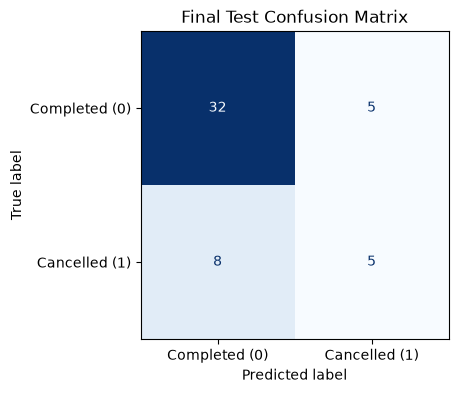

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 행은 실제 상태, 열은 예측 상태인 혼동행렬을 그린다.
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    labels=[0, 1],
    display_labels=["Completed (0)", "Cancelled (1)"],
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax,
)

ax.set_title("Final Test Confusion Matrix")
plt.show()

### STEP 9. 고정된 모델의 Final Test

#### 결과 관찰

Validation에서 선택한 Logistic Regression과 threshold 0.4를 고정한 뒤 Test 50건을 평가했다. Accuracy는 0.7400, Precision은 0.5000, Recall은 0.3846, F1은 0.4348이었다. 혼동행렬의 건수는 TN 32, FP 5, FN 8, TP 5이다.

#### 나의 해석과 판단

취소 주문 13건 중 5건을 취소로 예측했고 8건은 놓쳤다. 취소라고 예측한 10건 중 5건이 실제 취소였다. Validation에서 선택한 threshold를 Test 결과에 맞춰 다시 조정하지 않겠다.

#### 업무·분석적 의미

현재 설정으로는 일부 취소 위험 주문을 찾을 수 있지만, 실제 취소 주문을 놓치는 경우도 많다. 이 성능으로 어떤 조치를 할 수 있을지는 놓친 취소 주문과 잘못된 경고의 비용을 확인한 뒤 판단해야 한다.

#### 한계와 추가 확인 사항

Test에도 취소 주문은 13건뿐이어서 지표가 몇 건의 예측에 따라 달라질 수 있다. 이번 평가는 무작위 분할 데이터에 대한 결과이며, 미래 기간 주문에서의 성능을 증명하지는 않는다.

### 실제 결과의 시사점

Final Test에서 실제 취소 주문 13건 중 5건을 찾았지만 8건을 놓쳤다. 반면 완료 주문 37건 중 5건은 취소 위험으로 잘못 표시했다. 혼동행렬을 보면 Accuracy 0.74라는 숫자만으로는 알기 어려운 **취소 주문 누락(FN 8건)**을 확인할 수 있다.

이 결과는 현재 모델을 취소 여부를 자동으로 결정하는 용도로 사용하기보다, 담당자가 추가로 살펴볼 주문을 찾는 **참고 정보로 검토해야 함**을 시사한다. 다만 실제 사용 여부는 잘못된 경고 5건의 확인 비용과 취소 주문을 놓친 8건의 손실을 조사한 뒤 판단해야 한다.

Validation보다 Test의 Recall과 F1이 낮아졌지만, 이 결과를 보고 같은 Test에 맞춰 모델이나 threshold를 다시 선택하지 않는다. 추가 개선에는 새로운 검증 설계와 미래 기간 주문 데이터 평가가 필요하다.

### STEP 10. Confusion Matrix와 FP/FN 해석

## STEP 10. 혼동행렬과 FP/FN의 업무 의미

### 결과 관찰

Final Test의 혼동행렬은 다음과 같다.

| 구분 | 의미 | 건수 |
| --- | --- | ---: |
| TN | 완료 주문을 완료로 예측 | 32건 |
| FP | 완료 주문을 취소 위험으로 잘못 예측 | 5건 |
| FN | 취소 주문을 완료로 잘못 예측 | 8건 |
| TP | 취소 주문을 취소 위험으로 예측 | 5건 |

실제 취소 주문 13건 중 5건을 찾았고, 8건은 놓쳤다. 취소 위험으로 표시한 주문 10건 중 5건은 실제로 완료됐다.

### 나의 해석과 판단

이번 분석의 목적은 취소 위험 주문을 찾아보는 것이므로 **FN 8건**, 즉 취소 주문을 놓친 결과에 주목했다. 다만 FN만 줄이려고 더 많은 주문을 취소 위험으로 표시하면 FP가 증가할 수 있다. Final Test 결과를 보고 이미 고정한 threshold 0.4를 다시 조정하지는 않는다.

### 실제 업무에서 생길 수 있는 일

- **FP 5건:** 정상 주문을 담당자가 불필요하게 확인할 수 있다. 자동 알림을 보낸다면 고객에게 불필요한 메시지가 갈 수도 있다.
- **FN 8건:** 취소 위험 주문을 미리 확인할 기회를 놓친다. 다만 그 주문을 발견했더라도 실제 취소를 막을 수 있었는지는 이 데이터로 알 수 없다.
- **TP 5건:** 실제 취소 주문을 취소 위험으로 표시해 추가 확인 대상으로 삼을 수 있다.

### 시사점과 추가 확인 사항

현재 모델은 취소 주문을 일부 찾지만, 놓친 주문도 많다. 따라서 자동 조치에 바로 사용하기보다 **담당자의 확인을 돕는 참고 정보로 쓸 수 있을지 추가 검증**하는 편이 적절하다.

어떤 오류를 더 줄여야 하는지 결정하려면 정상 주문 1건을 확인하는 비용, 불필요한 알림의 영향, 취소 1건의 손실, 실제로 취소를 막을 수 있는 조치가 있는지를 알아야 한다. 예측 결과만으로 취소의 원인을 단정할 수 없다.

### STEP 11. Internal 결과와 Public 결과 구분

In [46]:
# 내부 분석용: 오류가 난 주문을 추적할 수 있도록 원본 식별자를 보관한다.
# 이 데이터프레임은 공개용으로 저장하거나 화면에 행 내용을 표시하지 않는다.
internal_predictions = pd.DataFrame({
    "source_index": X_test.index.to_numpy(),
    "order_id": model_data.loc[X_test.index, "order_id"].to_numpy(),
    "customer_id": model_data.loc[X_test.index, "customer_id"].to_numpy(),
    "actual_is_cancelled": y_test.to_numpy(),
    "predicted_is_cancelled": test_pred,
    "cancel_probability": test_cancel_probability,
    "model": frozen_model_name,
    "threshold": frozen_threshold,
})

# 공개용: 원본 행 번호와 주문·고객 ID를 제거한다.
public_predictions = internal_predictions.drop(
    columns=["source_index", "order_id", "customer_id"]
).reset_index(drop=True)

# 공개 결과 안에서만 사용하는 새 번호를 붙인다.
public_predictions.insert(
    0, "record_id", range(1, len(public_predictions) + 1)
)

# 원본 식별자가 공개 결과에 섞이지 않았는지 검사한다.
forbidden_public = {
    "source_index", "order_id", "customer_id", "product_id", "name"
}
public_overlap = sorted(forbidden_public & set(public_predictions.columns))

print("내부 결과 행 수:", len(internal_predictions))
print("공개 결과 행 수:", len(public_predictions))
print("공개 결과 컬럼:", public_predictions.columns.tolist())
print("공개 금지 컬럼 포함:", public_overlap)

assert len(public_predictions) == len(y_test)
assert not public_overlap

# 공개 가능한 결과만 미리 확인한다.
display(public_predictions.head())

내부 결과 행 수: 50
공개 결과 행 수: 50
공개 결과 컬럼: ['record_id', 'actual_is_cancelled', 'predicted_is_cancelled', 'cancel_probability', 'model', 'threshold']
공개 금지 컬럼 포함: []


,record_id,actual_is_cancelled,predicted_is_cancelled,cancel_probability,model,threshold
0,1,0,0,0.086732,Logistic Regression,0.4
1,2,0,0,0.251041,Logistic Regression,0.4
2,3,0,1,0.424714,Logistic Regression,0.4
3,4,0,0,0.083211,Logistic Regression,0.4
4,5,0,0,0.336564,Logistic Regression,0.4


In [47]:
# 공개 결과를 저장할 폴더를 준비한다.
reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

# 원본 식별자를 제거한 공개 결과만 저장한다.
public_path = reports_dir / "ch10_classification_predictions.csv"
public_predictions.to_csv(public_path, index=False, encoding="utf-8-sig")

# 저장된 파일을 다시 읽어 컬럼과 행 수를 확인한다.
saved_public = pd.read_csv(public_path)

print("저장 위치:", public_path)
print("저장된 행 수:", len(saved_public))
print("저장된 컬럼:", saved_public.columns.tolist())
print(
    "공개 금지 컬럼 포함:",
    sorted(forbidden_public & set(saved_public.columns)),
)

assert len(saved_public) == len(y_test)
assert not (forbidden_public & set(saved_public.columns))

저장 위치: C:\dev\llm-data-analysis-course-ch10\reports\ch10_classification_predictions.csv
저장된 행 수: 50
저장된 컬럼: ['record_id', 'actual_is_cancelled', 'predicted_is_cancelled', 'cancel_probability', 'model', 'threshold']
공개 금지 컬럼 포함: []


### STEP 11. 내부 결과와 공개 결과 구분

#### 결과 관찰

Final Test 예측 결과는 내부용과 공개용 모두 50행이다. 내부 결과에는 오류 분석을 위한 `source_index`, `order_id`, `customer_id`를 보관했다. 공개 결과에는 새로 부여한 `record_id`, 실제·예측 상태, 취소 점수, 모델명, threshold만 포함했다.

공개용 CSV `ch10_classification_predictions.csv`를 저장한 뒤 다시 읽어 확인했다. 저장된 파일에는 50행이 있으며, `source_index`, `order_id`, `customer_id`, `product_id`, `name`은 포함되지 않았다.

#### 나의 해석과 판단

FP와 FN의 원본 주문을 내부에서 조사하려면 식별자가 필요할 수 있다. 하지만 결과를 공개할 때는 그 식별자를 제거해야 하므로, 내부 분석용 결과와 공개용 결과를 분리했다. `record_id`는 공개 결과의 행을 구분하기 위해 새로 만든 번호다.

#### 업무·분석적 의미

모델 성능을 확인하는 일과 어떤 정보를 외부에 공개해도 되는지 검토하는 일은 별개다. 예측 결과를 공유할 때는 원본 주문·고객 ID가 실수로 포함되지 않았는지 저장된 파일까지 확인해야 한다.

#### 한계와 추가 확인 사항

이번 검사는 지정한 원본 식별자 컬럼이 공개 결과에 없는지 확인한 것이다. 실제 고객 데이터라면 다른 정보와 결합했을 때 개인을 다시 알아볼 수 있는지 등 추가적인 공개 범위 검토가 필요하다. 내부 결과는 공개 파일로 저장하지 않았다.

### STEP 12. Validation Evidence 확인

In [48]:
# STEP 12. 노트북에서 사용한 분석 규칙을 다시 점검한다.

# 세 분할의 행 번호가 서로 겹치지 않아야 한다.
train_ids = set(X_train.index)
val_ids = set(X_val.index)
test_ids = set(X_test.index)

splits_disjoint = (
    train_ids.isdisjoint(val_ids)
    and train_ids.isdisjoint(test_ids)
    and val_ids.isdisjoint(test_ids)
)

checks = {
    # completed=0, cancelled=1만 모델링했는가?
    "binary_target_contract": (
        set(y.unique()) == {0, 1}
        and set(target_orders["order_status"].unique()) == {"completed", "cancelled"}
        and (
            target_orders["is_cancelled"]
            == (target_orders["order_status"] == "cancelled").astype(int)
        ).all()
    ),

    # 정답·식별자·사후 정보가 모델 입력에 없는가?
    "forbidden_feature_overlap": not (set(feature_columns) & forbidden_features),

    # 병합에서 행이 늘거나 줄지 않고 모두 매칭됐는가?
    "strict_merge_contract": (
        len(model_data) == len(target_orders)
        and orders_without_items.empty
        and items_without_orders.empty
        and model_data["item_merge"].eq("both").all()
        and model_data["customer_merge"].eq("both").all()
    ),

    # 세 분할 모두 두 클래스가 있고, 행이 서로 겹치지 않는가?
    "all_splits_have_two_classes": (
        all(labels.nunique() == 2 for labels in [y_train, y_val, y_test])
        and splits_disjoint
        and len(y_train) + len(y_val) + len(y_test) == len(y)
    ),

    # 선택한 모델이 Validation 비교의 1순위인가?
    "selected_model_from_validation": (
        selected_model_name == ranked_models.iloc[0]["model"]
        and selected_model_name in trained_models
    ),

    # 선택한 threshold가 Validation 비교의 1순위인가?
    "selected_threshold_from_validation": np.isclose(
        selected_threshold, ranked_thresholds.iloc[0]["threshold"]
    ),

    # 저장된 공개 결과에 원본 식별자가 없는가?
    "public_prediction_privacy": (
        forbidden_public.isdisjoint(saved_public.columns)
        and len(saved_public) == len(public_predictions)
    ),

    # Test 성능 계산에 사용한 행 수가 실제 Test 행 수와 같은가?
    "test_rows_for_metrics": (
        len(y_test) == len(saved_public)
        == int(test_tn + test_fp + test_fn + test_tp)
    ),
}

validation_evidence = pd.DataFrame([
    {"check": name, "result": "PASS" if passed else "FAIL"}
    for name, passed in checks.items()
])

display(validation_evidence)
print("PASS:", (validation_evidence["result"] == "PASS").sum(), "/ 8")

assert all(checks.values()), "FAIL 항목의 원인을 확인해야 합니다."

,check,result
0,binary_target_contract,PASS
1,forbidden_feature_overlap,PASS
2,strict_merge_contract,PASS
3,all_splits_have_two_classes,PASS
4,selected_model_from_validation,PASS
5,selected_threshold_from_validation,PASS
6,public_prediction_privacy,PASS
7,test_rows_for_metrics,PASS


PASS: 8 / 8


### STEP 13. 전체 스크립트 재실행

In [49]:
# 노트북에서 직접 확인한 검증 결과를 별도 파일로 저장한다.
evidence_path = reports_dir / "ch10_classification_validation_notebook.csv"
validation_evidence.to_csv(evidence_path, index=False, encoding="utf-8-sig")

print("검증 결과 저장 위치:", evidence_path)
print("저장된 검사 수:", len(validation_evidence))

검증 결과 저장 위치: C:\dev\llm-data-analysis-course-ch10\reports\ch10_classification_validation_notebook.csv
저장된 검사 수: 8


### STEP 12. Validation Evidence 확인

#### 결과 관찰

노트북에서 타깃 정의, 금지 특징 제외, 병합 관계, 데이터 분할, Validation 기반 모델·threshold 선택, 공개 결과의 식별자 제거, Test 행 수를 검사했다. 총 8개 항목이 모두 PASS였다. 검사 결과는 `ch10_classification_validation_notebook.csv`에 저장했다.

#### 나의 해석과 판단

이번 점검으로 현재 노트북의 변수와 결과가 정해둔 분석 규칙에 맞는지 확인했다. 특히 주문 병합의 미매칭이 없고, 공개 예측 파일에 원본 식별자 컬럼이 없으며, 선택된 모델과 threshold가 Validation 비교 결과와 일치한다.

#### 업무·분석적 의미

성능 수치와 별도로 타깃·특징·병합·평가 절차를 점검하면 분석 결과가 어떻게 만들어졌는지 확인하기 쉽다. 오류가 발견되면 성능 해석에 앞서 해당 데이터 또는 절차를 수정해야 한다.

#### 한계와 추가 확인 사항

8개 PASS는 노트북의 코드와 현재 데이터에 대한 검사 결과다. 고객 정보가 실제 주문 시점에 사용 가능했는지, 미래 주문에서도 성능이 유지되는지, 운영상 FP/FN 비용이 적절한지까지 증명하지는 않는다. 다음 단계에서 공식 전체 스크립트를 재실행해 별도의 Validation Evidence도 확인한다.

In [50]:
# 주문일과 가입일을 비교할 수 있도록 날짜형으로 바꾼다.
date_check = orders[
    ["order_id", "customer_id", "order_date", "order_status"]
].merge(
    customers[["customer_id", "signup_date"]],
    on="customer_id",
    how="left",
    validate="many_to_one",
)

date_check["order_date"] = pd.to_datetime(date_check["order_date"])
date_check["signup_date"] = pd.to_datetime(date_check["signup_date"])

# 주문 이후에 가입한 것으로 기록된 행을 찾는다.
late_signup = date_check.loc[
    date_check["signup_date"] > date_check["order_date"]
]

print("전체 날짜 역전 주문:", len(late_signup))
print("상태별 건수:")
print(late_signup["order_status"].value_counts())
print("이번 모델링 대상에 포함된 건수:",
      late_signup["order_status"].isin(["completed", "cancelled"]).sum())

전체 날짜 역전 주문: 56
상태별 건수:
order_status
completed    35
refunded     11
cancelled    10
Name: count, dtype: int64
이번 모델링 대상에 포함된 건수: 45
